<a href="https://colab.research.google.com/github/JainJiyaa/Flower-Classification-using-CNN/blob/main/Flower_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pathlib

In [ ]:
data_dir = pathlib.Path("/content/drive/MyDrive/PGA 39/DL/CNN/flower_photos")

In [ ]:
print("Classes:", [item.name for item in data_dir.iterdir() if item.is_dir()])

Classes: ['tulips', 'sunflowers', 'daisy', 'dandelion', 'roses']


In [ ]:
import tensorflow as tf

batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
class_names = train_ds.class_names
print("Class Names:", class_names)

Class Names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


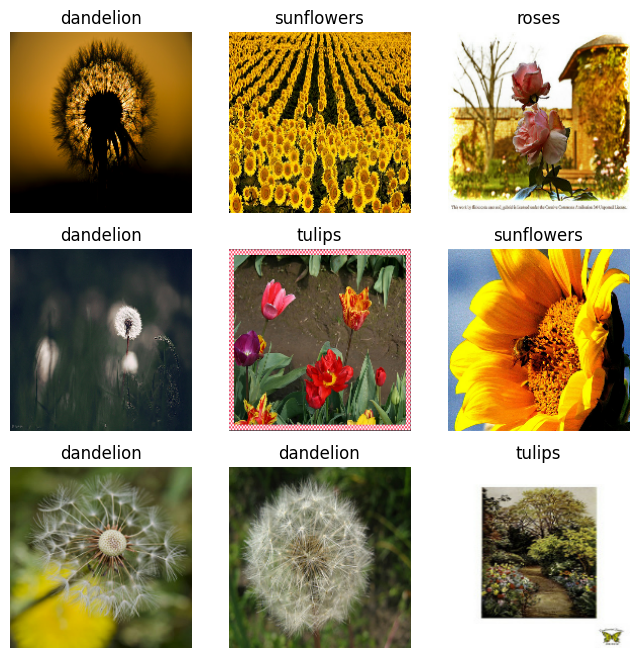

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for images, labels in train_ds.take(10):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (224, 224)
batch_size = 32

# Data augmentation and normalization
data_gen = ImageDataGenerator(
    rescale=1.0 / 255.0,  # Normalize pixel values to [0, 1]
    rotation_range=30,    # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,       # Shearing
    zoom_range=0.2,        # Zooming
    horizontal_flip=True,  # Horizontal flipping
    validation_split=0.2   # Split dataset into training and validation sets
)

# Training data generator
train_generator = data_gen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  # One-hot encode labels
    subset='training'          # Use training subset
)

# Validation data generator
validation_generator = data_gen.flow_from_directory(
    data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  # One-hot encode labels
    subset='validation'        # Use validation subset
)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


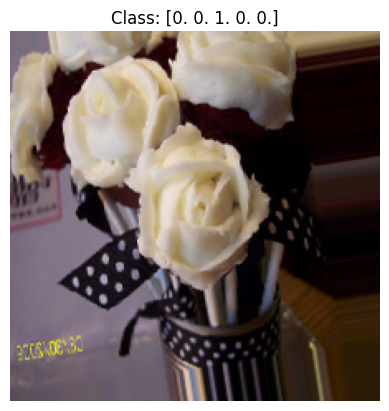

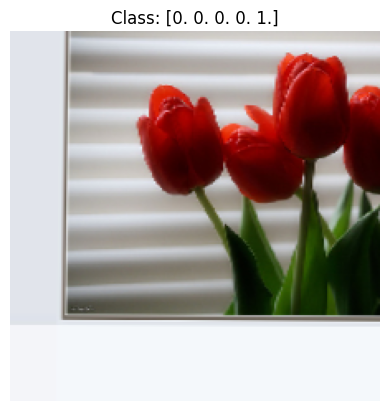

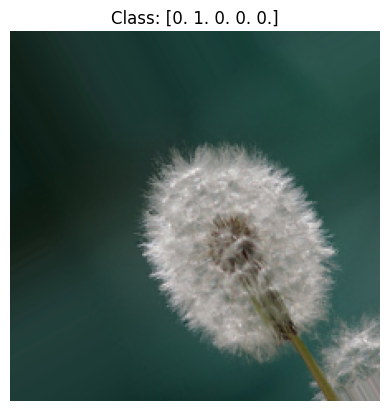

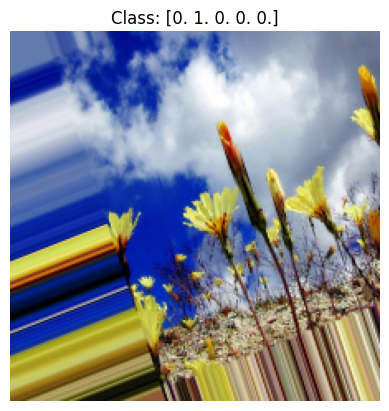

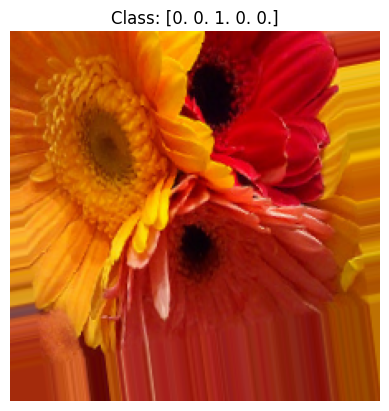

In [ ]:
import matplotlib.pyplot as plt
images, labels = next(train_generator)

# Display the first 5 images
for i in range(5):
    plt.imshow(images[i])
    plt.title(f"Class: {labels[i]}")
    plt.axis('off')
    plt.show()

In [ ]:
class_names = list(train_generator.class_indices.keys())
print(class_names)


['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


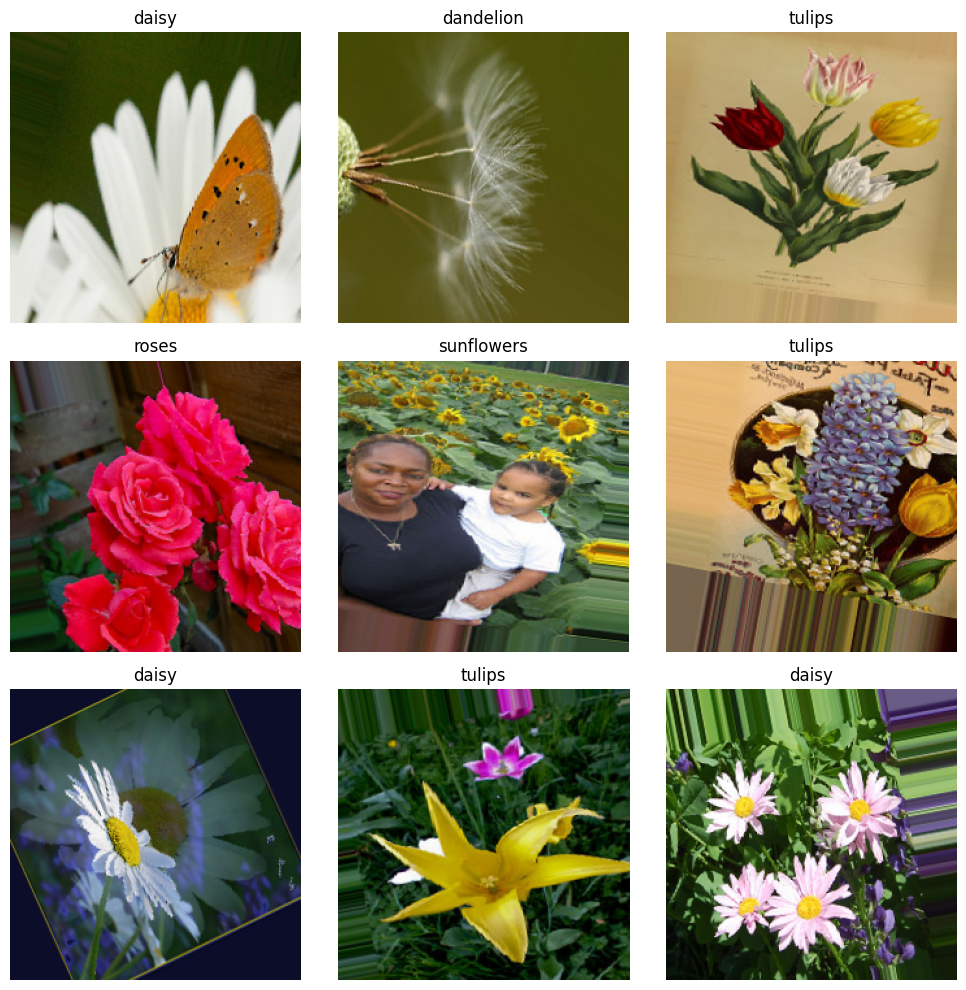

In [ ]:
import numpy as np
class_names = list(train_generator.class_indices.keys())


plt.figure(figsize=(10, 10))


images, labels = next(train_generator)

for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

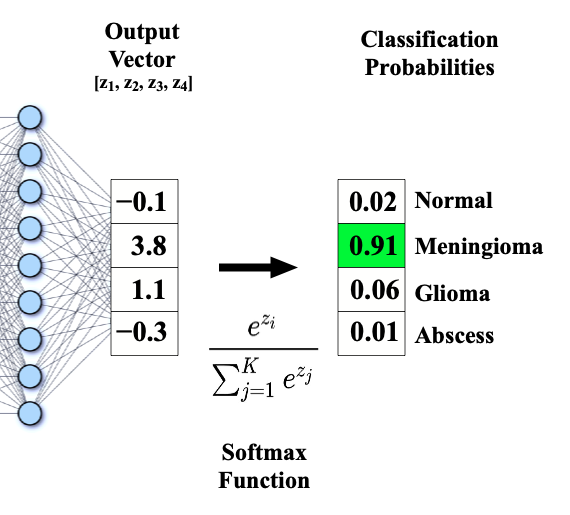

In [ ]:
import numpy as np

def softmax(z):
  '''Return the softmax output of a vector.'''
  exp_z = np.exp(z)
  sum = exp_z.sum()
  softmax_z = np.round(exp_z/sum,3)
  return softmax_z

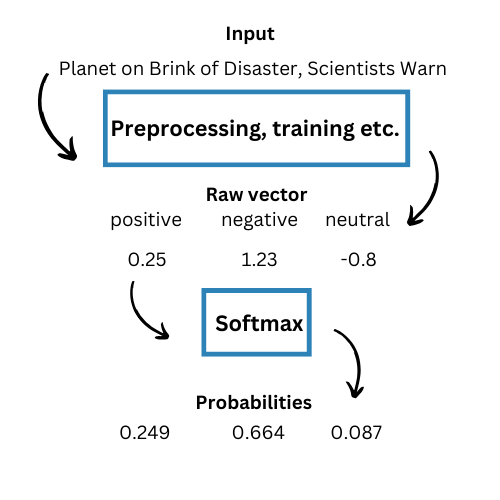

In [ ]:
z = [0.25, 1.23, -0.8]
softmax(z)

array([0.249, 0.664, 0.087])

1. **Rescaling Layer:**

* layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)): This layer rescales the pixel values from the range [0, 255] to [0, 1] by dividing by 255. It also specifies the input shape, which includes the height and width of the image and the number of color channels (3 for RGB).
2. **Convolutional Layers:**

* layers.Conv2D(16, 3, padding='same', activation='relu'): This layer creates 16 convolutional filters of size 3x3. The padding='same' argument ensures that the output size is the same as the input size by adding zero padding around the edges. The activation function relu (Rectified Linear Unit) is applied to introduce non-linearity.
* layers.MaxPooling2D(): This layer performs max pooling with a 2x2 filter, which reduces the spatial dimensions of the output by a factor of 2.
* layers.Conv2D(32, 3, padding='same', activation='relu'): Similar to the first convolutional layer, but with 32 filters.
* layers.MaxPooling2D(): Another max pooling layer.
* layers.Conv2D(64, 3, padding='same', activation='relu'): Similar to the previous convolutional layers, but with 64 filters.
* layers.MaxPooling2D(): Another max pooling layer.
3. **Flatten Layer**:

* layers.Flatten(): This layer flattens the 3D output from the convolutional layers into a 1D vector, making it suitable for the fully connected layers that follow.

4. **Fully Connected (Dense) Layers**:

* layers.Dense(128, activation='relu'): This fully connected layer has 128 units with ReLU activation, adding more capacity for learning complex patterns.

* layers.Dense(num_classes, activation='softmax'): The output layer with num_classes units (5 in this case) and a softmax activation function, which is suitable for multi-class classification. The softmax function converts the output to a probability distribution over the classes.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

num_classes = 5

# Assuming img_height and img_width are defined somewhere
img_height = 224  # Replace with your actual image height
img_width = 224   # Replace with your actual image width

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1. **Optimizer:**

* optimizer='adam': The Adam optimizer is an efficient and popular choice for training deep learning models. It combines the advantages of two other extensions of stochastic gradient descent, namely AdaGrad and RMSProp, which makes it well-suited for problems with sparse gradients and noisy data.
2. **Loss Function:**

* loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True): The sparse categorical crossentropy loss function is used for multi-class classification problems. The from_logits=True argument indicates that the model's output layer does not have a softmax activation function applied to it, meaning the outputs are raw logits. If your model's final layer uses a softmax activation (as in your model definition), you should set from_logits=False.
3. **Metrics:**

* metrics=['accuracy']: This specifies that the accuracy metric should be used to evaluate the model's performance during training and testing.


In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [ ]:
epochs=20
history = model.fit(
  train_generator,
  validation_data=validation_generator,
  epochs=epochs
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 995s 11s/step - accuracy: 0.2135 - loss: 1.6084 - val_accuracy: 0.2449 - val_loss: 1.6020
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.2446 - loss: 1.6002 - val_accuracy: 0.2449 - val_loss: 1.6005
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.2523 - loss: 1.5985 - val_accuracy: 0.2449 - val_loss: 1.6002
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.2395 - loss: 1.6008 - val_accuracy: 0.2449 - val_loss: 1.6002
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.2463 - loss: 1.5988 - val_accuracy: 0.2449 - val_loss: 1.6001
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.2384 - loss: 1.6014 - val_accuracy: 0.2449 - val_loss: 1.6001
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.2432 - loss: 1.5998 - val_accuracy: 0.2449 - val_loss: 1.6001
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 243s 3s/step - accuracy: 0.2493 - loss: 1.6002 - val_accuracy: 0.2449 - 

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(validation_generator)

# Print the accuracy
print(f'Test accuracy: {accuracy * 100:.2f}%')

23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.2574 - loss: 1.5965
Test accuracy: 24.49%


In [ ]:
!pip install gradio

In [ ]:
from PIL import Image
import numpy as np

import gradio as gr

def predict_image(image):
    image = image.resize((224, 224))  # Resize the input image
    image_array = tf.keras.preprocessing.image.img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)
    image_array /= 255.0  # Normalize the image

    predictions = model.predict(image_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])

    return predicted_class, confidence


iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Textbox(label="Predicted Class"),
        gr.Textbox(label="Confidence"),
    ],
    title="Flower Image Classifier",
    description="Upload an image to classify the type of flower.",
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8bad2f196754d3769.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
